# skyplot Package Test Notebook

This notebook validates `skyplot` against a user-provided HEALPix map file.

Update the map path in Cell 3 before running all cells.

In [1]:
from pathlib import Path

import healpy as hp
import numpy as np

from skyplot import (
    AVAILABLE_PROJECTIONS,
    RESOLUTION_PRESETS,
    equidistantconic,
    mollweide,
    orthographic,
    platecarree,
    sample_at_angles,
    sample_full_sky,
    save_figure,
)

print("Available projections:", AVAILABLE_PROJECTIONS)
print("Resolution presets:", RESOLUTION_PRESETS)

Available projections: ('mollweide', 'orthographic', 'platecarree', 'equidistantconic')
Resolution presets: {'low': (480, 960), 'medium': (720, 1440), 'high': (1440, 2880)}


In [2]:
# Replace this with your HEALPix FITS map path at runtime.
map_path = Path("/Users/shamik/Documents/Work/new_co_model/data/co10_spatialWF_template_masked.fits")

if not map_path.exists():
    raise FileNotFoundError(
        f"Set map_path to an existing HEALPix file. Current value: {map_path}"
    )

hp_map = hp.read_map(map_path, field=0, verbose=False)
print("Map loaded:", map_path)
print("npix:", hp_map.size, "nside:", hp.get_nside(hp_map))
print("dtype:", hp_map.dtype)

Map loaded: /Users/shamik/Documents/Work/new_co_model/data/co10_spatialWF_template_masked.fits
npix: 12582912 nside: 1024
dtype: >f8


/var/folders/yy/4xf19n1n7_31nlkz7lv1wh980000gn/T/ipykernel_69002/3246899581.py:9: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  hp_map = hp.read_map(map_path, field=0, verbose=False)


/var/folders/yy/4xf19n1n7_31nlkz7lv1wh980000gn/T/ipykernel_63812/1996031245.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_mesh.show()


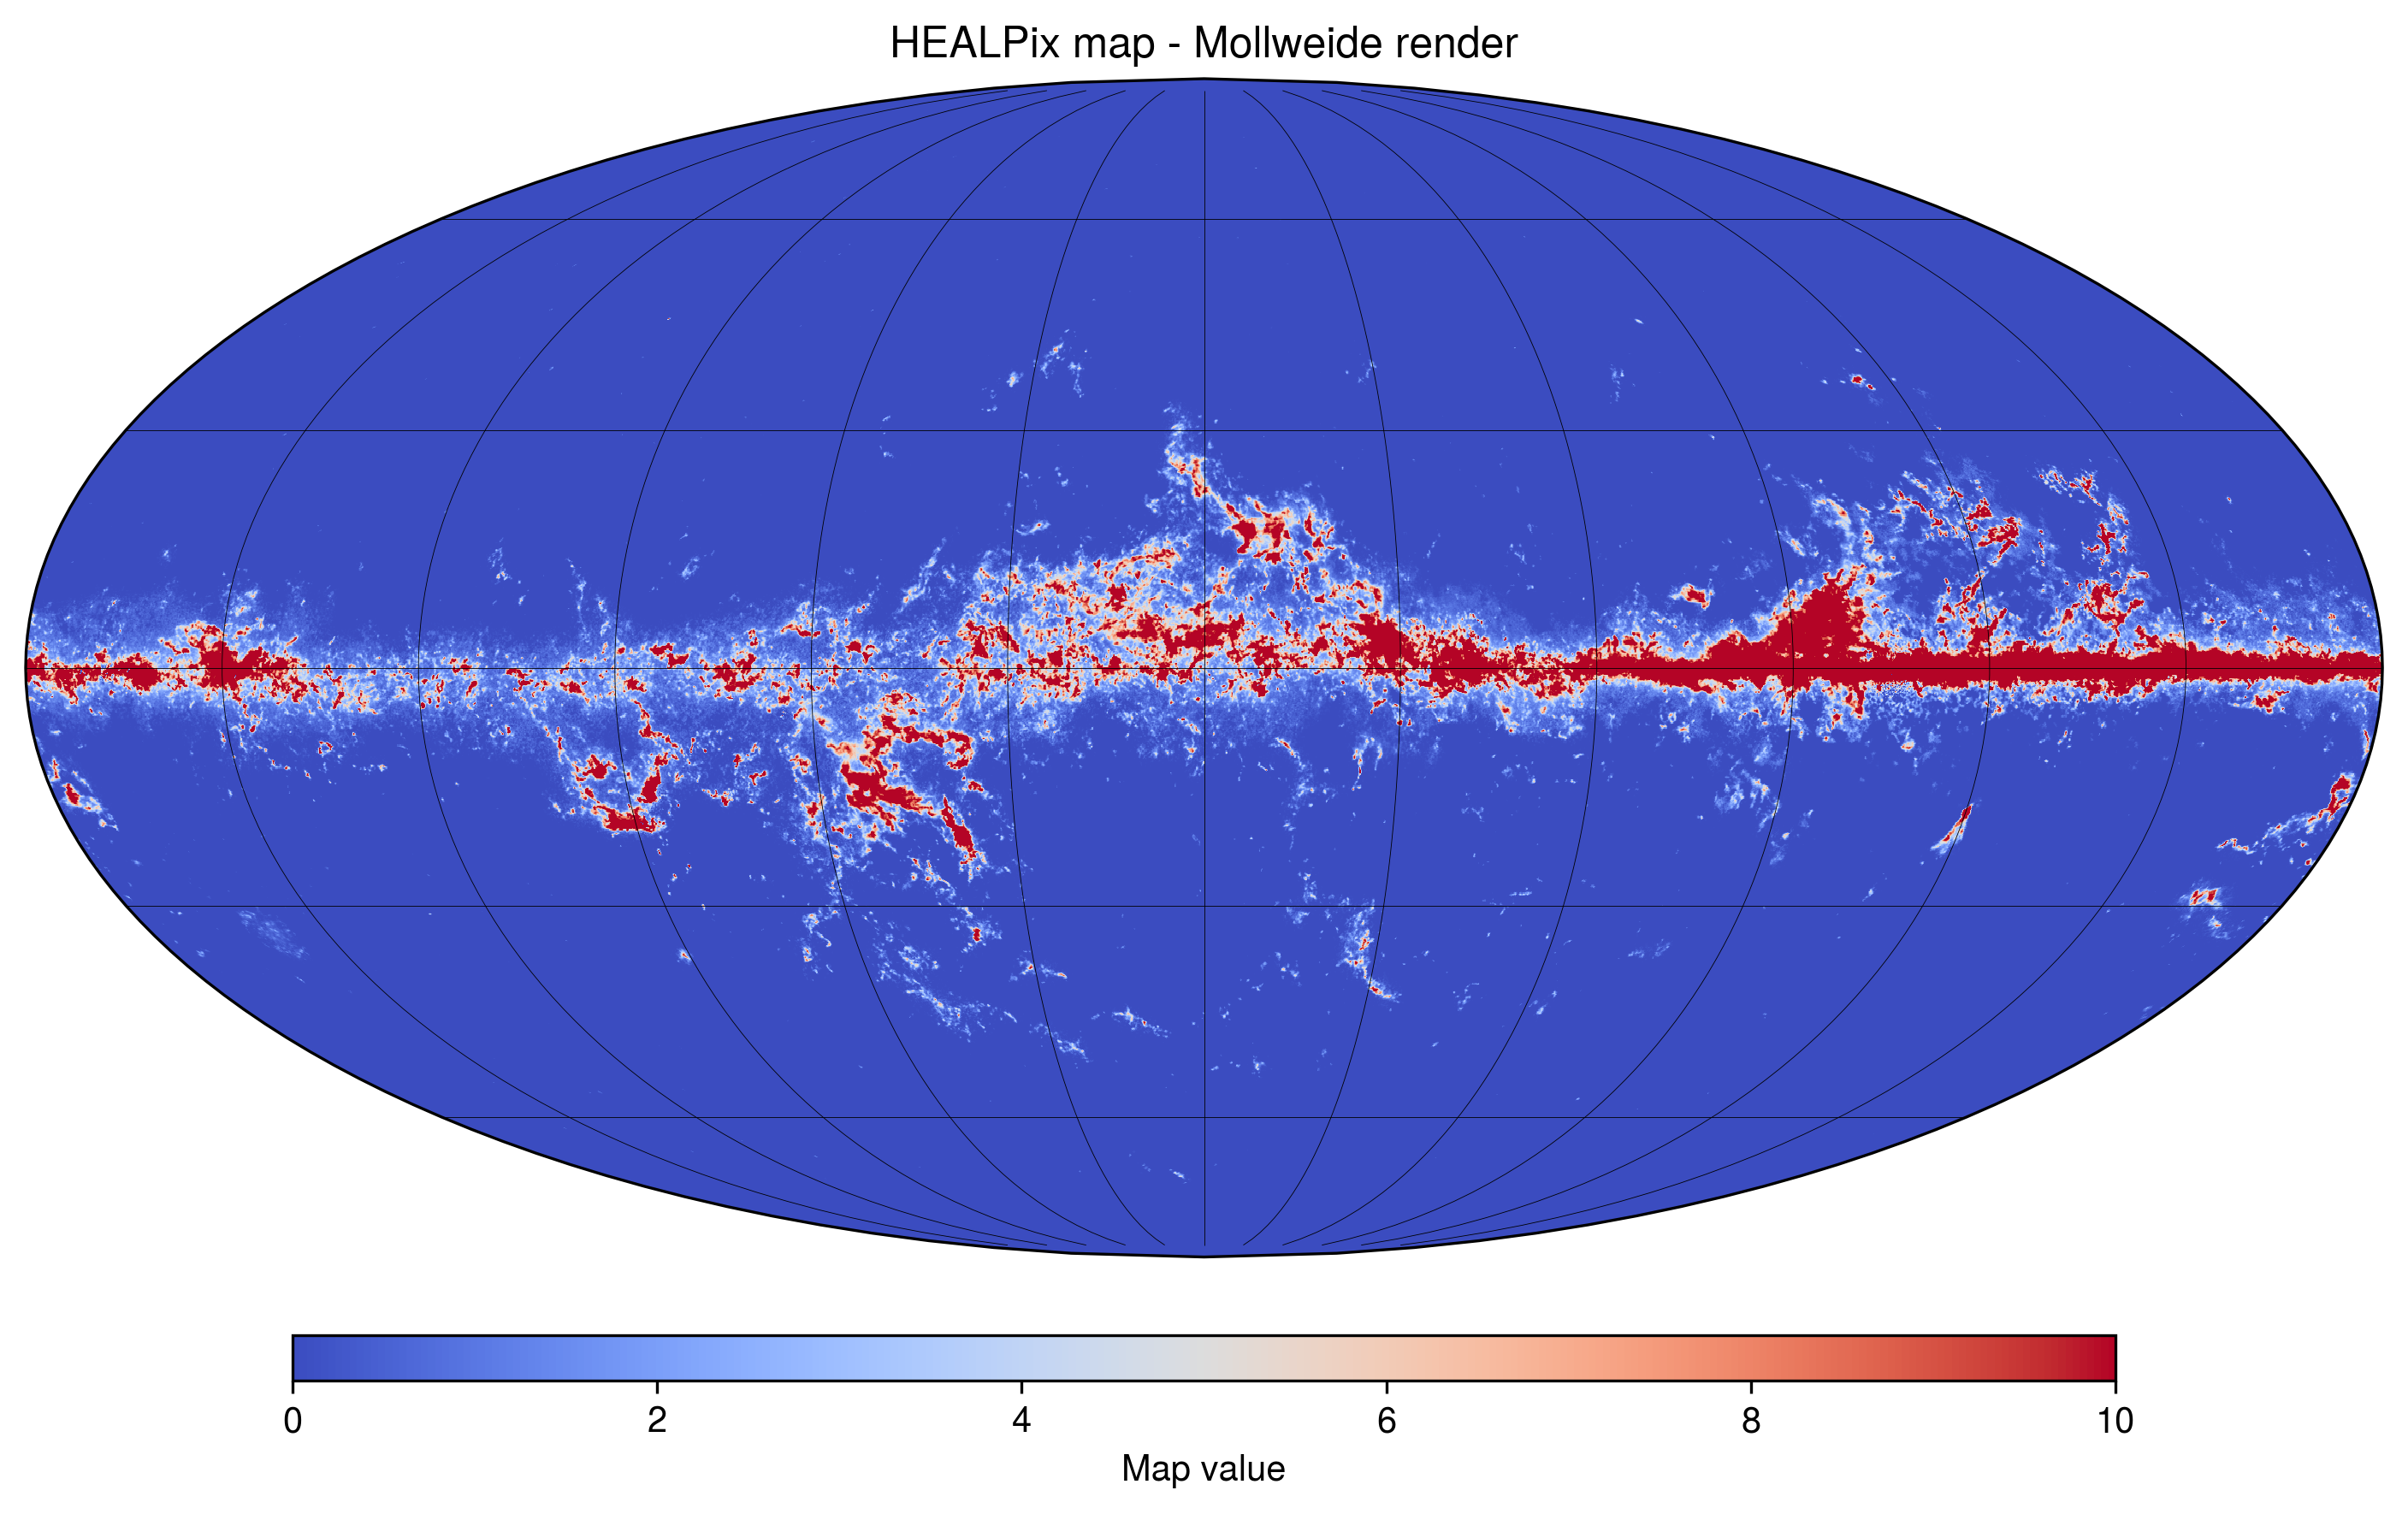

In [3]:
# Mollweide rendering with Matplotlib backend.
fig_mesh = mollweide(
    hp_map,
    projection_kwargs={"central_longitude": -120.0},
    resolution='high',
    # medium resolution is the default
    cmap="coolwarm",  # from colormaps package
    figsize=(12, 6),
    vmin=0.,
    vmax=10.0,
    dpi=300,
    title="HEALPix map - Mollweide render",
)
fig_mesh.show()

/var/folders/yy/4xf19n1n7_31nlkz7lv1wh980000gn/T/ipykernel_69002/3421156512.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_markers.show()


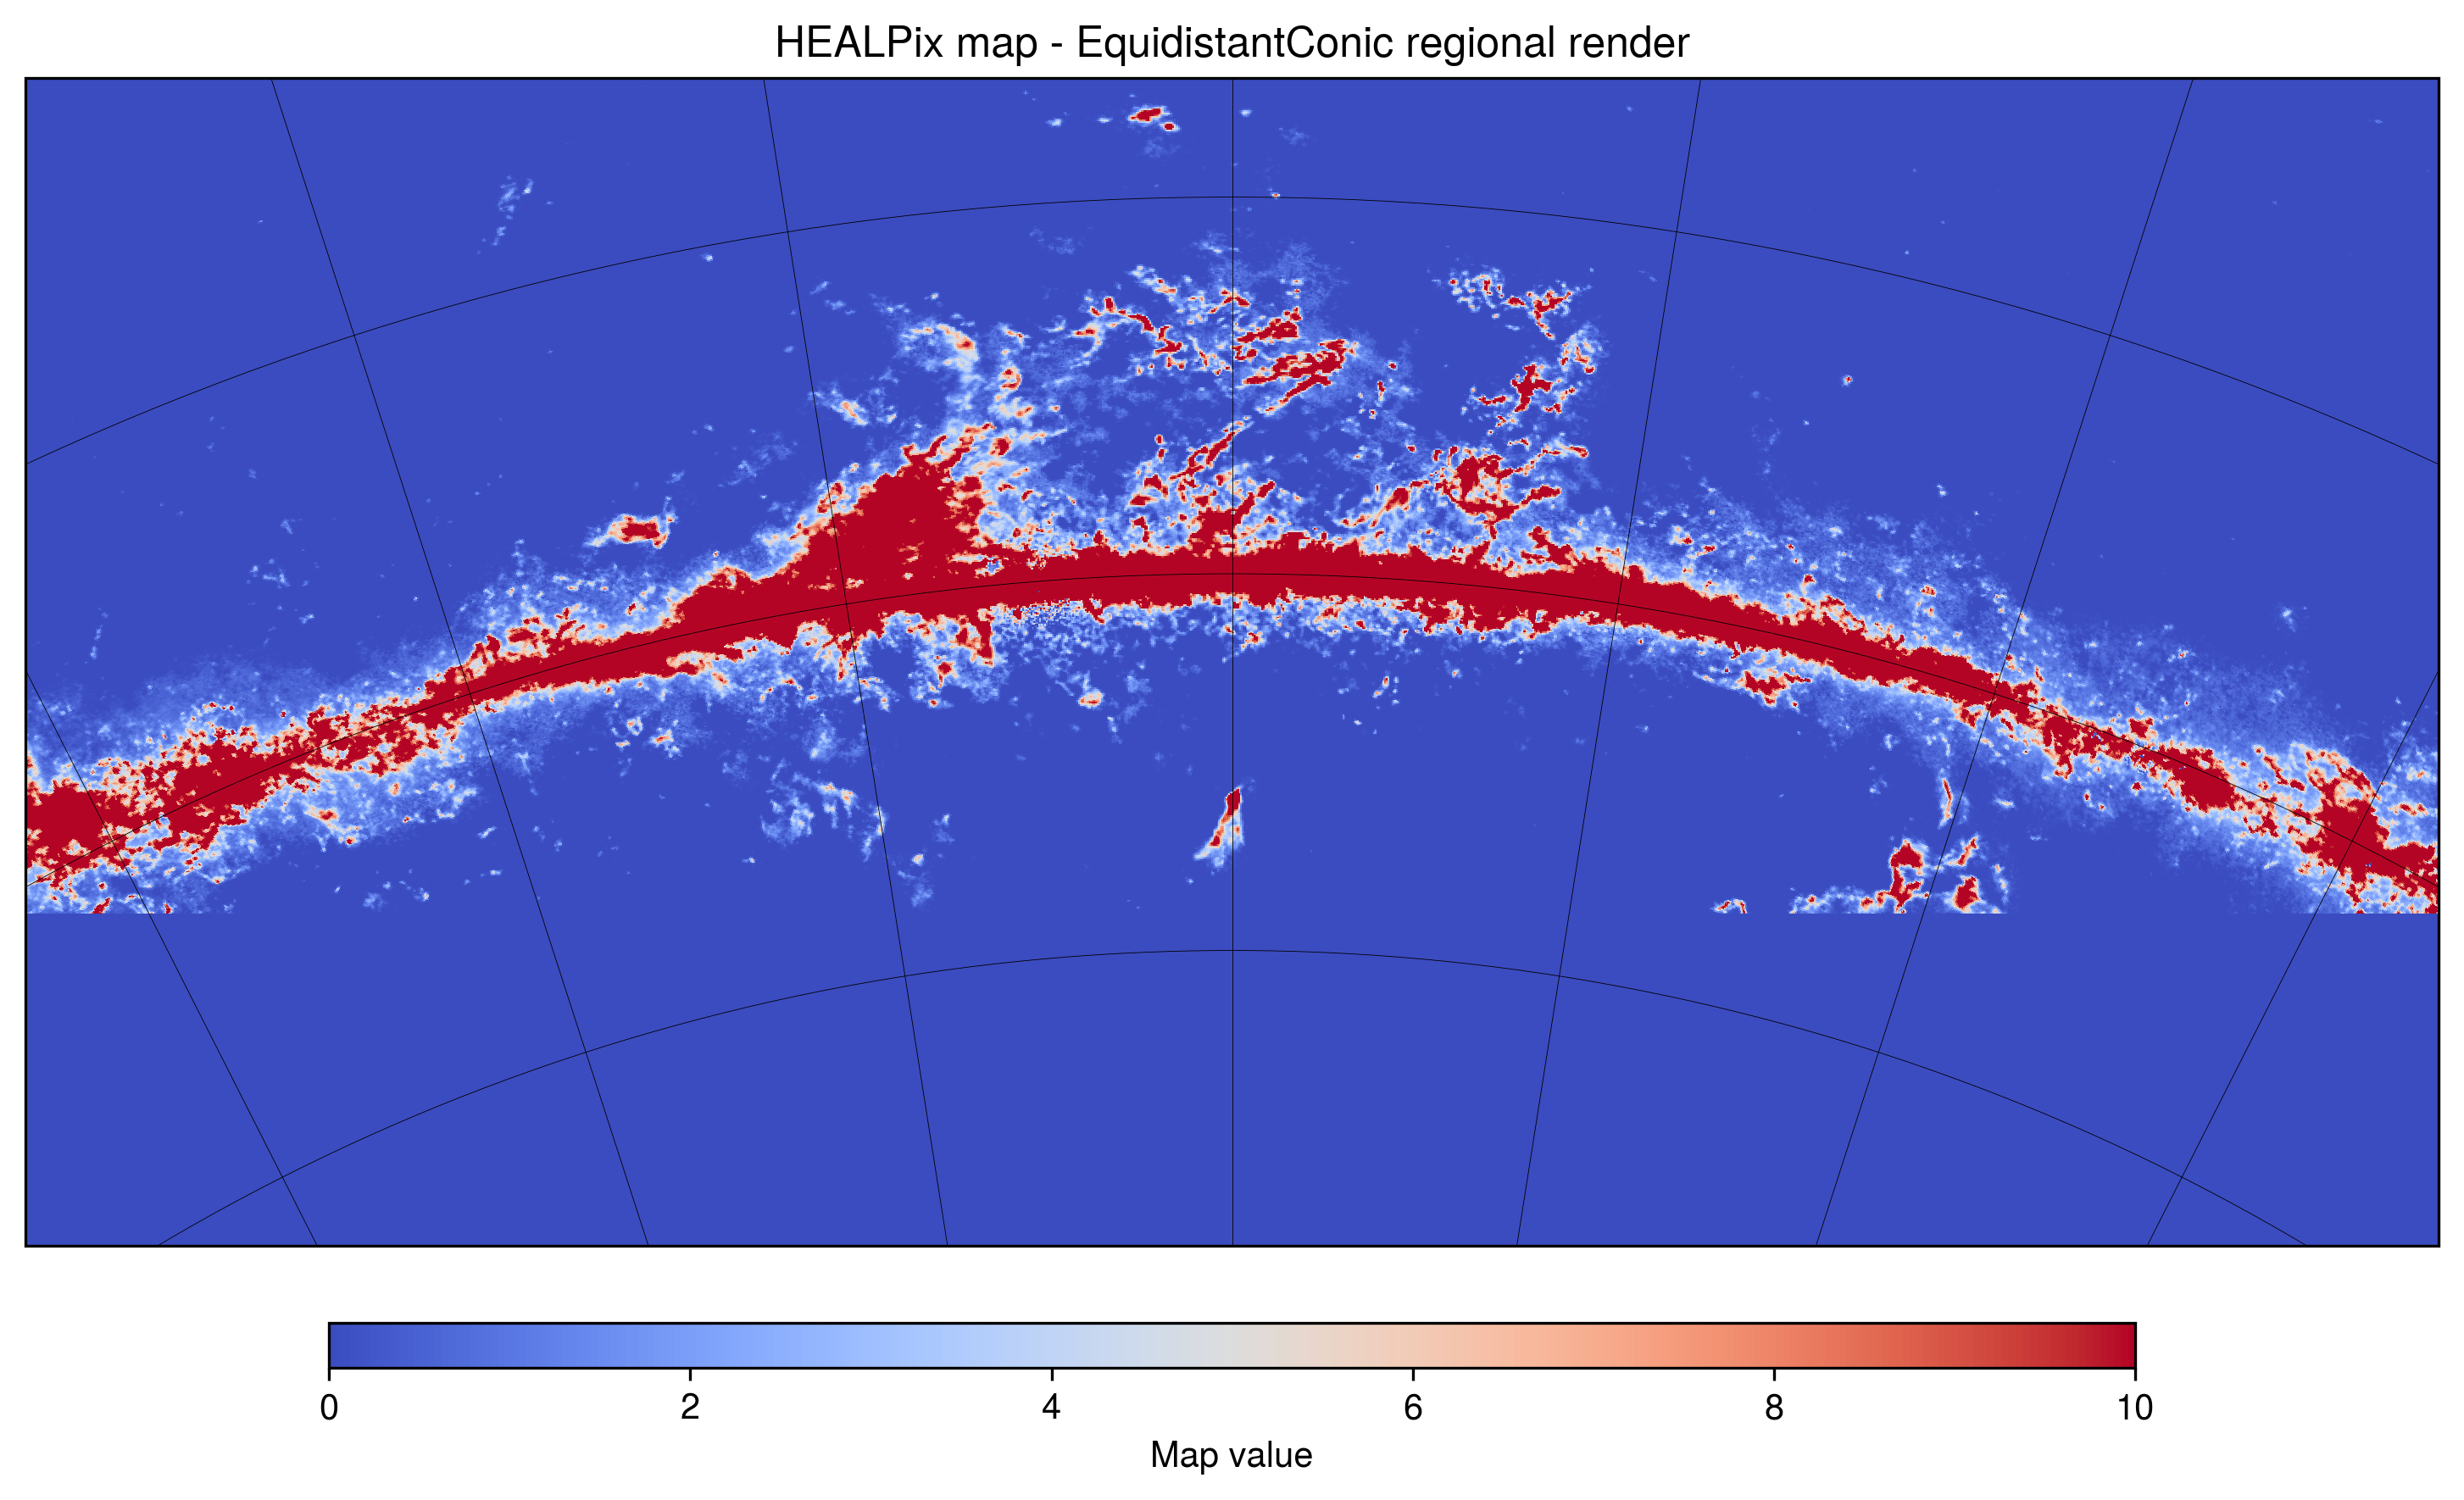

In [ ]:
# EquidistantConic rendering with custom central latitude/longitude.
fig_markers = equidistantconic(
    hp_map,
    projection_kwargs={
        "central_longitude": 0.0,
        "central_latitude": 0.0,
        "standard_parallels": (-30.0, -5.0),
        "cutoff": -90.0,
    },
    extent=(-80.0, 80.0, -40.0, 40.0),  # lon_min, lon_max, lat_min, lat_max
    resolution="high",
    cmap='coolwarm',
    vmin=0.,
    vmax=10.0,
    figsize=(12, 6),
    dpi=300,
    title="HEALPix map - EquidistantConic regional render",
)
fig_markers.show()

In [ ]:
# Compare all supported projections quickly.
projection_functions = {
    "mollweide": mollweide,
    "orthographic": orthographic,
    "platecarree": platecarree,
    "equidistantconic": equidistantconic,
}
figures = {}

for name, proj_fn in projection_functions.items():
    figures[name] = proj_fn(
        hp_map,
        resolution="low",
        title=f"Projection: {name}",
    )

figures["mollweide"].show()
print("Created figures for:", list(figures))

Saved:
 - notebook_outputs/mesh_map.html
 - notebook_outputs/mesh_map.json
 - notebook_outputs/mesh_map.png


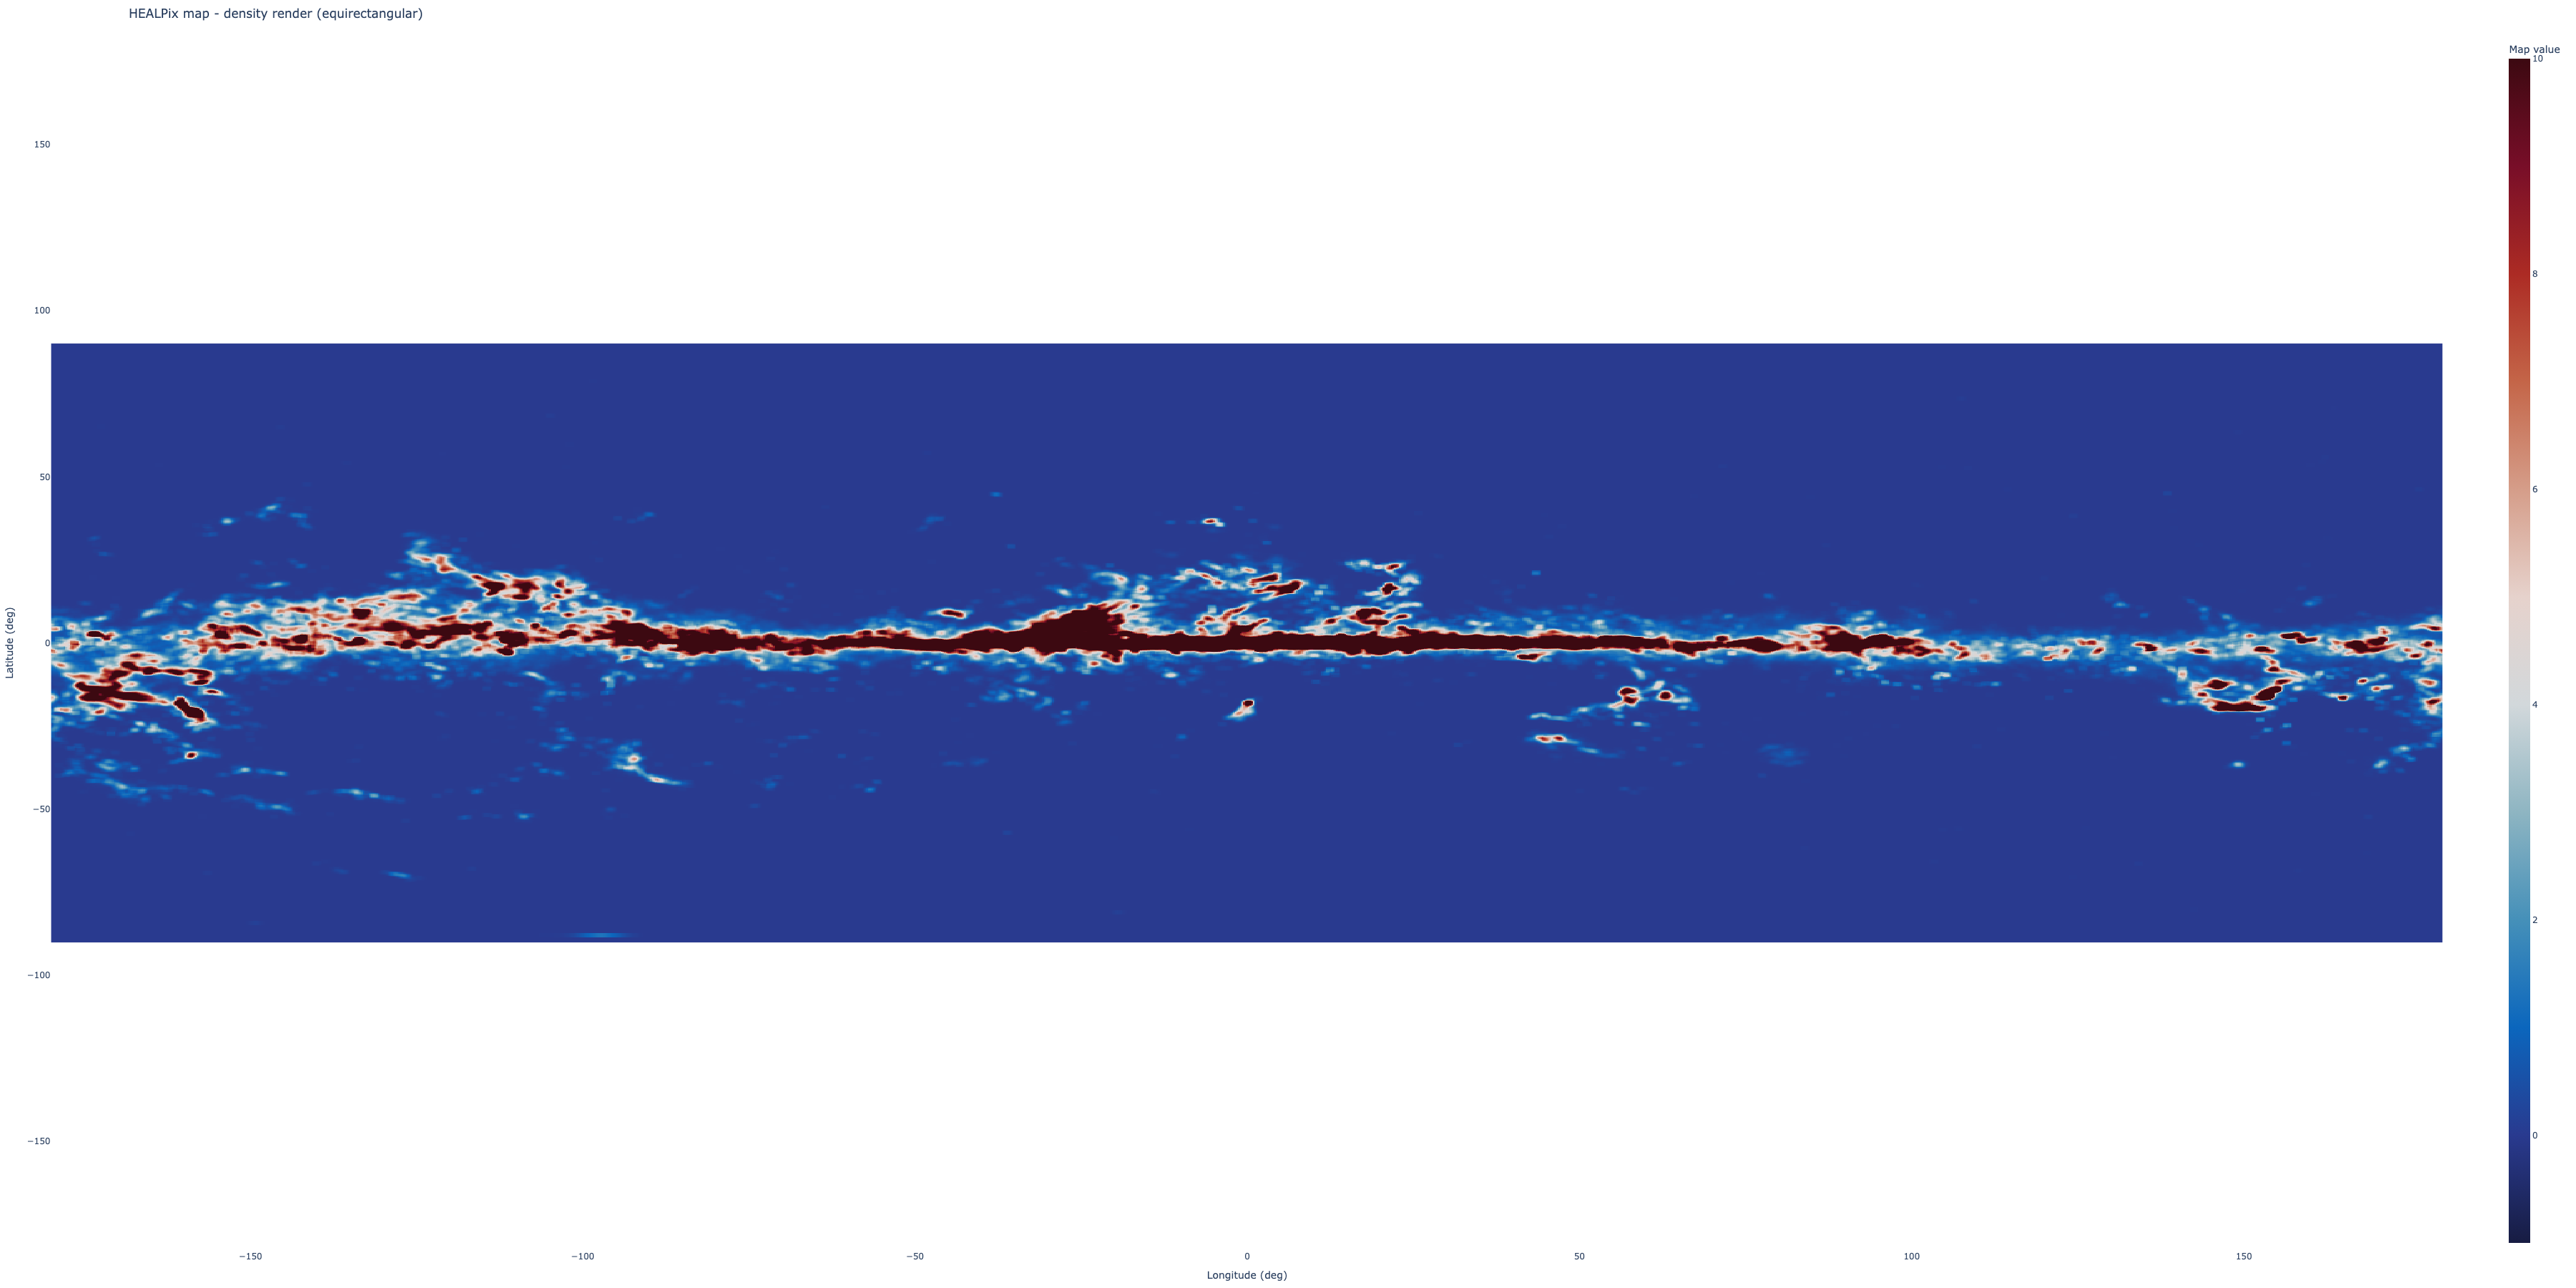

In [4]:
from IPython.display import Image, display

# Export tests: interactive + static.
out_dir = Path("notebook_outputs")
out_dir.mkdir(exist_ok=True)

html_path = save_figure(fig_mesh, out_dir / "mesh_map.html")
json_path = save_figure(fig_mesh, out_dir / "mesh_map", output_format="json")
png_path = save_figure(fig_mesh, out_dir / "mesh_map.png", figsize=(12, 6), dpi=300)

print("Saved:")
print(" -", html_path)
print(" -", json_path)
print(" -", png_path)

if png_path.exists():
    display(Image(filename=str(png_path), width=1200, retina=True))


In [ ]:
# Optional 2D WCS/ndmap-style input test (instead of 1D HEALPix).
class _LinearDummyWCS:
    def __init__(self, nrows, ncols):
        self.nrows = nrows
        self.ncols = ncols

    def all_world2pix(self, world, origin):
        arr = np.asarray(world, dtype=float)
        lon = arr[:, 0]
        lat = arr[:, 1]
        x = ((lon + 180.0) / 360.0) * (self.ncols - 1)
        y = ((lat + 90.0) / 180.0) * (self.nrows - 1)
        return np.column_stack([x, y])

wcs_data = np.random.default_rng(0).normal(size=(180, 360))
wcs_obj = _LinearDummyWCS(*wcs_data.shape)

fig_wcs = mollweide(
    wcs_data,
    wcs=wcs_obj,
    resolution="low",
    title="2D WCS-backed map via mollweide",
)
fig_wcs.show()